# 📘 Tutorial 2: Multi-Objective BO and Pareto-Optimal Decision-Making

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Tutorial 1**, we moved from idealised noiseless BO to a more realistic setting where observations were **noisy and uncertain**.

In particular, we saw that once BO no longer observes the true latent objective value directly, the optimisation problem is no longer only about asking:

> **which point looks best according to the acquisition function?**

Instead, the workflow also needs to ask:

- whether the best noisy observation should be trusted,
- whether a low-looking value may simply be a favourable noise draw,
- whether a promising point should be repeated,
- whether the model recommendation is more meaningful than the raw best measurement,
- and whether the acquisition function properly accounts for uncertainty in the current best latent value.

That established noisy BO as a decision-making problem under measurement uncertainty.

In this tutorial, we take the next step:

> **what changes when there is not just one objective to optimise, but several objectives that may compete with one another?**

That is the focus of this notebook.

This is an important shift.

In many earlier BO examples, the goal was to optimise a single scalar objective:

$$
\max_x f(x)
$$

or, after a sign change, to minimise a single scalar objective.

That setting is useful, but it is often too simple for realistic experimental optimisation.

In many scientific and engineering problems, a good experiment is not judged by one number alone.

For example, in electrolyte formulation optimisation, we may care about both:

- **Coulombic efficiency**,
- and **charging capacity**.

A formulation with very high capacity may not have the best efficiency.
A formulation with excellent efficiency may not deliver the highest capacity.
A balanced formulation may be preferable even if it is not individually best in either objective.

So the optimisation problem is no longer simply:

$$
\max_x f(x).
$$

Instead, it becomes:

$$
\max_x \left(f_1(x), f_2(x), \dots, f_m(x)\right).
$$

That small change has large consequences.

There may be no single point that is best in every objective.
The optimiser may need to discover a set of good trade-offs rather than one optimum.
Progress can no longer be measured only by the best value found so far.
And the final recommendation may depend on scientific priorities, thresholds, or preference rules.

So this tutorial is not mainly about replacing the BO loop.

It is about learning how the interpretation of BO changes when **trade-offs between objectives** become part of the optimisation problem.

To make this concrete, the notebook uses a synthetic **electrolyte formulation** problem with two continuous input variables:

- salt concentration,
- additive fraction.

The two objectives are:

- maximise Coulombic efficiency,
- maximise charging capacity.

Because the objective functions are synthetic, we can visualise the full objective landscapes, approximate the true Pareto frontier on a dense grid, and compare BO behaviour against a random Sobol baseline.

Those diagnostics let us see directly whether multi-objective BO is learning a useful trade-off frontier rather than merely finding isolated good points.

The notebook then introduces the central concepts needed for multi-objective BO:

- **Pareto dominance**,
- **Pareto-optimal points**,
- **the Pareto frontier**,
- **hypervolume**,
- and **expected hypervolume improvement**.

The main BO workflow uses **qExpectedHypervolumeImprovement**, or **qEHVI**.

qEHVI is the multi-objective analogue of improvement-based acquisition.

Instead of asking how much a candidate improves the current best scalar value, it asks:

> **how much is this candidate expected to improve the dominated hypervolume of the current Pareto frontier?**

That is the key algorithmic idea of the notebook.

This notebook therefore asks several core questions:

- why single-objective BO is not enough when objectives compete,
- what Pareto dominance means,
- how to identify observed Pareto points,
- how hypervolume turns a Pareto set into a scalar progress metric,
- how qEHVI proposes candidates by expected hypervolume improvement,
- how qEHVI compares with random Sobol search under the same evaluation budget,
- and how to choose one final formulation from a Pareto set using decision rules.

This is also where the notebook connects directly to realistic experimental optimisation.

In a real campaign, researchers are often not asking only:

> **which experiment maximises one performance metric?**

They are more often asking:

> **which experiments represent the best trade-offs between several competing goals?**

That is the multi-objective BO question.

---

**This tutorial is designed to shift perspective**
- from *“BO searches for one best objective value”*
- to *“BO learns a frontier of best available trade-offs.”*

---

**The emphasis is on developing intuition for**
- why multi-objective optimisation usually produces a Pareto frontier rather than one optimum,
- why dominated points are not rational final choices,
- why hypervolume is useful as a progress metric,
- why the reference point affects hypervolume and qEHVI behaviour,
- why qEHVI is the natural improvement-based acquisition function for noiseless multi-objective BO,
- and why final decision-making still requires scientific preferences after the Pareto set has been found.

---

**Key ideas explored include**
- defining a synthetic two-objective electrolyte formulation problem,
- visualising competing objective landscapes,
- computing an approximate true Pareto frontier on a dense grid,
- identifying observed Pareto points from an initial design,
- choosing and interpreting a hypervolume reference point,
- fitting one `SingleTaskGP` per objective using `ModelListGP`,
- using `qExpectedHypervolumeImprovement` to propose new candidates,
- comparing qEHVI against a random Sobol baseline,
- tracking hypervolume progress over BO steps,
- mapping Pareto-optimal formulations back into input space,
- and applying decision rules to choose one final formulation from the Pareto set.

---

This tutorial serves as the bridge from:

- **noisy and replication-aware BO** in Tutorial 1,
- to **richer BO settings where objectives, fidelities, contexts, and structures become more complex** in the rest of Part 6.

In other words:

- **Tutorial 1** showed how BO changes when observations are noisy and the best measured value may not be trustworthy,
- and **Tutorial 2** now asks what happens when there are multiple desirable outcomes and no single universal best point.

---

**Recommended prerequisites**
- Completion of **Tutorial 1 of Part 6**
- Familiarity with Gaussian Process surrogates and acquisition functions in BoTorch
- Familiarity with the standard sequential BO loop
- Basic understanding of expected improvement or LogEI
- Basic awareness of noisy BO concepts such as posterior uncertainty and model-based recommendations
- Some intuition for trade-offs between competing experimental objectives

---

**Author**: Angze Li

**Last updated**: 2026-04-21

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from botorch.models import SingleTaskGP, ModelListGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.utils.multi_objective.box_decompositions import NondominatedPartitioning
from botorch.acquisition.multi_objective.monte_carlo import qExpectedHypervolumeImprovement
from botorch.sampling.normal import SobolQMCNormalSampler

from gpytorch.mlls import SumMarginalLogLikelihood

warnings.filterwarnings("ignore")

torch.set_default_dtype(torch.double)


def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)


def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    ax.tick_params(axis="both", labelsize=14)

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

## 1. Setting up a multi-objective electrolyte optimisation problem

We begin by defining the synthetic experimental problem used throughout this notebook.

The motivating example is **electrolyte formulation optimisation**.

In a real battery or electrochemical materials workflow, we rarely care about only one performance metric. A formulation that gives excellent capacity may not be the most stable. A formulation that gives excellent efficiency may not deliver the highest usable capacity.

So instead of asking for a single best scalar value, we often need to reason about competing objectives.

That is the main reason multi-objective BO is important.

---

### Why this is not a single-objective problem

In this tutorial, the input space has two formulation variables:

- **salt concentration**, scaled to the interval $[0,1]$,
- **additive fraction**, also scaled to the interval $[0,1]$.

The output has two objectives:

- **Coulombic efficiency**, which we want to maximise,
- **charging capacity**, which we also want to maximise.

So the optimisation problem is not

$$
\max_x f(x),
$$

but instead

$$
\max_x \left(f_1(x), f_2(x)\right),
$$

where $f_1(x)$ is Coulombic efficiency and $f_2(x)$ is charging capacity.

The difficulty is that the two objectives do not necessarily have the same optimum.

A highly stable electrolyte formulation may favour high Coulombic efficiency, while a more aggressive formulation may deliver higher capacity but lower efficiency.

So there may be no single formulation that is best in both objectives at once.

---

### The role of the synthetic objective

The function `electrolyte_objectives(X)` defines a synthetic two-objective landscape.

It is not intended to be a real battery model. Instead, it is a controlled teaching example designed to behave like a realistic trade-off problem.

The first objective, Coulombic efficiency, favours a relatively stable region of formulation space.

The second objective, charging capacity, favours a different and more aggressive region.

This creates the central structure needed for multi-objective optimisation:

> improving one objective may require sacrificing the other.

That trade-off is what makes the Pareto frontier meaningful.

---

### Why multi-objective BO is useful here

If we collapsed the two objectives into a single weighted score immediately, we would have to choose the weights before understanding the trade-off structure.

That can be risky.

For example, choosing too much weight on capacity might select a formulation with poor efficiency. Choosing too much weight on efficiency might ignore useful high-capacity formulations.

Multi-objective BO takes a different approach.

Instead of immediately deciding which objective matters most, it tries to learn the set of best trade-offs.

That set is called the **Pareto frontier**.

A formulation is Pareto-optimal if there is no other formulation that improves one objective without worsening at least one other objective.

So the goal is not simply to find one best point.

The goal is to learn a useful frontier of formulations such as:

- high-efficiency but moderate-capacity formulations,
- high-capacity but lower-efficiency formulations,
- and balanced compromise formulations in between.

---

### What this cell defines

This cell sets up:

- the random seed for reproducibility,
- the two-dimensional formulation space,
- the names of the input variables and objectives,
- the synthetic two-objective electrolyte function,
- and a dense grid used for visualisation and approximate ground-truth diagnostics.

The printed output reports the ranges of the two objectives over the grid.

For this example, Coulombic efficiency varies over a relatively narrow range, while charging capacity varies over a much larger numerical range.

This difference in scale is one reason why later decision rules should be interpreted carefully: objective values often need to be normalised before using weighted scores.

---

### Key takeaway

This cell establishes the central problem of the tutorial:

> we are no longer optimising one number; we are optimising a trade-off between multiple desirable outcomes.

In this electrolyte example, the aim is to understand how BO can search efficiently for formulations that balance Coulombic efficiency and charging capacity, rather than pretending that one scalar objective fully captures the experimental goal.

In [2]:
seed = 12
set_seed(seed)

bounds = torch.tensor(
    [[0.0, 0.0], [1.0, 1.0]],
    dtype=torch.double,
)

input_names = ["salt concentration", "additive fraction"]
objective_names = ["Coulombic efficiency", "Charging capacity"]


def electrolyte_objectives(X):
    if X.ndim == 1:
        X = X.unsqueeze(0)

    salt = X[..., 0]
    additive = X[..., 1]

    # Objective 1: Coulombic efficiency
    # Favours stable, moderately concentrated formulations.
    efficiency = (
        0.965
        + 0.030 * torch.exp(-((salt - 0.35) / 0.22) ** 2 - ((additive - 0.28) / 0.18) ** 2)
        - 0.020 * torch.exp(-((salt - 0.85) / 0.25) ** 2 - ((additive - 0.78) / 0.22) ** 2)
        - 0.012 * (salt - 0.55) ** 2
        - 0.010 * (additive - 0.35) ** 2
        + 0.003 * torch.sin(8.0 * salt + 2.0 * additive)
    )

    # Objective 2: charging capacity
    # Favours more aggressive formulations, but with diminishing returns.
    capacity = (
        145.0
        + 72.0 * torch.exp(-((salt - 0.72) / 0.24) ** 2 - ((additive - 0.62) / 0.28) ** 2)
        + 18.0 * salt
        + 10.0 * additive
        - 22.0 * torch.exp(-((salt - 0.25) / 0.18) ** 2 - ((additive - 0.25) / 0.18) ** 2)
        + 4.0 * torch.sin(5.0 * salt - 1.5 * additive)
    )

    efficiency = efficiency.clamp(0.88, 0.997)
    capacity = capacity.clamp(110.0, 235.0)

    return torch.stack([efficiency, capacity], dim=-1)

n_grid = 100

x1 = torch.linspace(0.0, 1.0, n_grid)
x2 = torch.linspace(0.0, 1.0, n_grid)

X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
grid_X = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=-1)
grid_Y = electrolyte_objectives(grid_X)

print("Efficiency range:", float(grid_Y[:, 0].min()), "to", float(grid_Y[:, 0].max()))
print("Capacity range:", float(grid_Y[:, 1].min()), "to", float(grid_Y[:, 1].max()))

Efficiency range: 0.9441960876196617 to 0.9939438365825255
Capacity range: 132.8574149935737 to 235.0


## 2. Visualising the two objective landscapes

This cell visualises the two objective functions over the electrolyte formulation space.

The input space is two-dimensional:

- salt concentration on the horizontal axis,
- additive fraction on the vertical axis.

For every point on the dense grid, we evaluate both objectives:

- Coulombic efficiency,
- charging capacity.

The two contour plots then show how each objective changes across the same formulation space.

---

### Why this visualisation matters

This is mainly a diagnostic and intuition-building plot.

Before introducing Pareto frontiers, hypervolume, or multi-objective acquisition functions, it is useful to see the two landscapes separately.

The key point is that the two objectives have different preferred regions.

The printed output confirms this:

- the best Coulombic efficiency occurs near `salt concentration ≈ 0.33` and `additive fraction ≈ 0.27`,
- the best charging capacity occurs near `salt concentration ≈ 0.68` and `additive fraction ≈ 0.61`.

So the formulation that maximises efficiency is not the same as the formulation that maximises capacity.

That is exactly why this is a multi-objective optimisation problem.

---

### What the stars represent

Each subplot marks the best grid point for that objective with a star.

In the left panel, the star marks the formulation with the highest Coulombic efficiency.

In the right panel, the star marks the formulation with the highest charging capacity.

Because these stars appear in different regions of the design space, the figure makes the trade-off visible before we even enter objective space.

---

### Key takeaway

This cell shows that the two objectives favour different parts of the electrolyte formulation space.

There is therefore no obvious single formulation that is best for everything.

That motivates the next step: instead of searching for one scalar optimum, we need to understand the set of best trade-offs between efficiency and capacity.

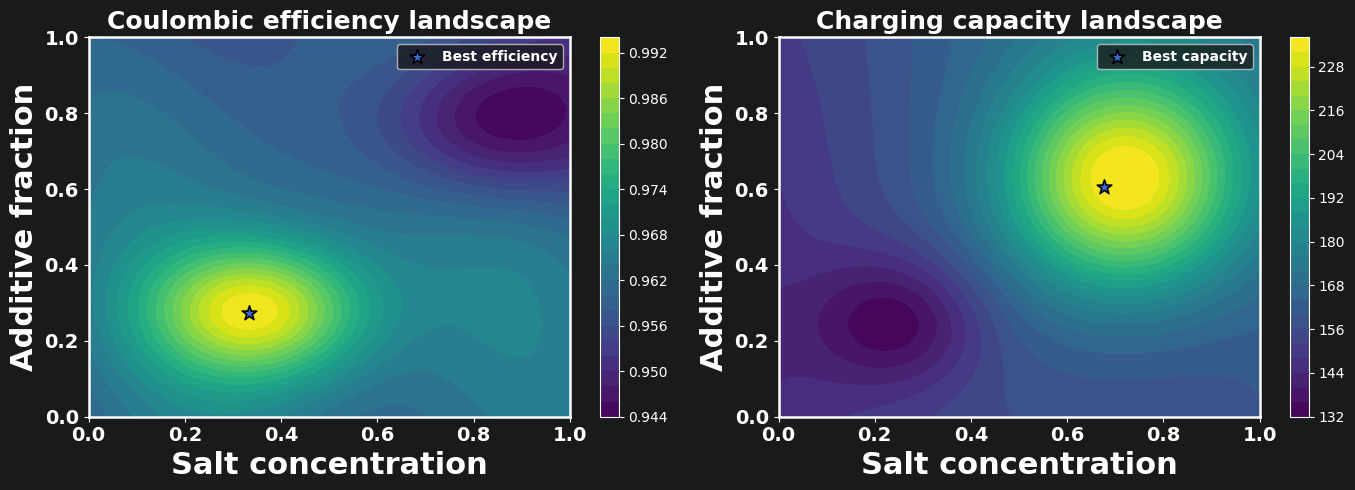

Best efficiency location: [0.33333333 0.27272727]
Best capacity location: [0.67676768 0.60606061]


In [3]:
eff_grid = grid_Y[:, 0].reshape(n_grid, n_grid)
cap_grid = grid_Y[:, 1].reshape(n_grid, n_grid)

best_eff_idx = torch.argmax(grid_Y[:, 0])
best_cap_idx = torch.argmax(grid_Y[:, 1])

best_eff_x = grid_X[best_eff_idx]
best_cap_x = grid_X[best_cap_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

c1 = axes[0].contourf(
    X1.numpy(),
    X2.numpy(),
    eff_grid.numpy(),
    levels=30,
)
axes[0].scatter(
    float(best_eff_x[0]),
    float(best_eff_x[1]),
    s=120,
    marker="*",
    edgecolor="black",
    lw=1.2,
    label="Best efficiency",
)
axes[0].set_title("Coulombic efficiency landscape", fontsize=18, fontweight="bold")
axes[0].set_xlabel("Salt concentration", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Additive fraction", fontsize=22, fontweight="bold")
axes[0].legend(prop={"size": 10, "weight": "bold"})
style_ax(axes[0])
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(
    X1.numpy(),
    X2.numpy(),
    cap_grid.numpy(),
    levels=30,
)
axes[1].scatter(
    float(best_cap_x[0]),
    float(best_cap_x[1]),
    s=120,
    marker="*",
    edgecolor="black",
    lw=1.2,
    label="Best capacity",
)
axes[1].set_title("Charging capacity landscape", fontsize=18, fontweight="bold")
axes[1].set_xlabel("Salt concentration", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Additive fraction", fontsize=22, fontweight="bold")
axes[1].legend(prop={"size": 10, "weight": "bold"})
style_ax(axes[1])
fig.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()

print("Best efficiency location:", best_eff_x.numpy())
print("Best capacity location:", best_cap_x.numpy())

## 3. Pareto frontier and objective-space trade-off

This cell moves from the two separate objective landscapes into **objective space**.

Instead of plotting the formulation variables directly, we now plot each possible formulation by its two objective values:

- $x$-axis: Coulombic efficiency,
- $y$-axis: Charging capacity.

Each point in the scatter plot represents one formulation from the dense grid.

So a point further to the right has higher Coulombic efficiency, and a point higher up has higher charging capacity.

Because both objectives are being maximised, the ideal direction is therefore toward the **upper-right** of the plot.

---

### Pareto dominance

To understand the Pareto frontier, we first need the idea of **dominance**.

Suppose we compare two formulations, $A$ and $B$.

Formulation $A$ dominates formulation $B$ if $A$ is at least as good as $B$ in every objective, and strictly better in at least one objective.

For this two-objective example, $A$ dominates $B$ if:

$$
f_{\text{eff}}(A) \ge f_{\text{eff}}(B)
$$

and

$$
f_{\text{cap}}(A) \ge f_{\text{cap}}(B),
$$

with at least one of these inequalities being strict.

If a formulation is dominated, it is not a good final choice, because another formulation exists that improves one objective without sacrificing the other.

---

### What the Pareto frontier means

A formulation is **Pareto-optimal** if no other formulation dominates it.

The **Pareto frontier** is the set of all Pareto-optimal formulations in objective space.

In practical terms, a point on the Pareto frontier represents a best available trade-off.

You cannot move to another formulation with higher charging capacity without losing some Coulombic efficiency, and you cannot move to another formulation with higher Coulombic efficiency without losing some charging capacity.

That is the key idea:

> Pareto-optimal points are not individually “best at everything”; they are the points where improvement in one objective requires compromise in another.

---

### What the figure shows

The faint scatter points show all grid formulations in objective space.

The highlighted curve shows the approximate true Pareto frontier computed from the dense grid using `is_non_dominated`.

The frontier lies along the upper-right boundary of the cloud of possible formulations.

This is exactly what we expect for a maximisation problem: the Pareto frontier is made of points that are difficult to improve upon because they already sit on the best trade-off boundary.

The shape of the frontier shows the trade-off between the two objectives:

- on the high-capacity end, formulations achieve very large charging capacity but have lower Coulombic efficiency,
- on the high-efficiency end, formulations achieve very high Coulombic efficiency but have lower charging capacity,
- between them are compromise formulations that balance both objectives.

So the frontier is not a single optimum.

It is a menu of best trade-offs.

---

### Why this matters for multi-objective BO

In single-objective BO, progress can be measured by the best function value found so far.

In multi-objective BO, there is usually no single best value.

Instead, the goal is to improve the Pareto frontier: we want to discover formulations that push the trade-off boundary upward and to the right.

This is why multi-objective BO needs different diagnostics and acquisition functions.

The optimiser is no longer only asking:

> which point has the highest objective value?

It is asking:

> which next experiment is most likely to improve the set of best trade-offs?

---

### Key takeaway

This cell computes and visualises the approximate true Pareto frontier of the synthetic electrolyte problem.

The plot shows that Coulombic efficiency and charging capacity cannot both be maximised by the same formulation.

Instead, the problem contains a frontier of trade-offs, and the goal of multi-objective BO is to learn and improve that frontier efficiently.

Number of grid points: 10000
Number of approximate true Pareto points: 229


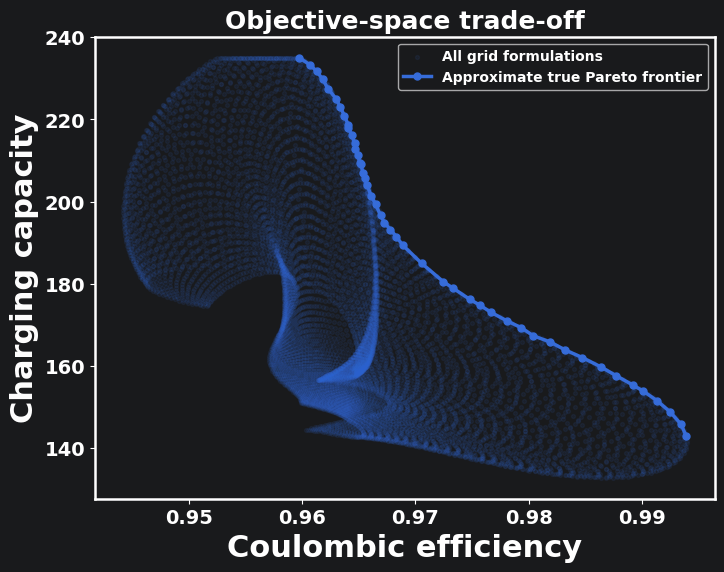

In [4]:
true_pareto_mask = is_non_dominated(grid_Y)
true_pareto_X = grid_X[true_pareto_mask]
true_pareto_Y = grid_Y[true_pareto_mask]

# Sort by efficiency for cleaner plotting
sort_idx = torch.argsort(true_pareto_Y[:, 0])
true_pareto_X = true_pareto_X[sort_idx]
true_pareto_Y = true_pareto_Y[sort_idx]

print("Number of grid points:", grid_X.shape[0])
print("Number of approximate true Pareto points:", true_pareto_Y.shape[0])

fig, ax = plt.subplots(figsize=(8, 6))

thin = 5

ax.scatter(
    grid_Y[:, 0],
    grid_Y[:, 1],
    s=8,
    alpha=0.08,
    label="All grid formulations",
)

ax.plot(
    true_pareto_Y[::thin, 0],
    true_pareto_Y[::thin, 1],
    "-o",
    markersize=5,
    lw=2.5,
    label="Approximate true Pareto frontier",
)
ax.set_title("Objective-space trade-off", fontsize=18, fontweight="bold")
ax.set_xlabel("Coulombic efficiency", fontsize=22, fontweight="bold")
ax.set_ylabel("Charging capacity", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 4. Initial design and observed Pareto points

We now generate the initial dataset that starts the multi-objective BO workflow.

As in earlier BO tutorials, the optimiser does not begin with a surrogate model trained on the whole function. It begins with a small set of initial evaluations.

Here, those initial formulations are selected using Sobol sampling over the two-dimensional input space.

The initial dataset contains:

- salt concentration,
- additive fraction,
- Coulombic efficiency,
- and charging capacity.

This gives the first observed picture of the trade-off between the two objectives.

---

### Why we need an initial design

Bayesian optimisation is sequential.

Before we can fit a GP surrogate or optimise a multi-objective acquisition function, we need some initial observations.

The line

`n_init = 10`

means that we begin with 10 initial electrolyte formulations.

These are not chosen by BO yet. They are the starting dataset from which the first surrogate model will be built.

---

### Observed Pareto points

The code then computes

`observed_pareto_mask = is_non_dominated(train_Y_init)`.

This identifies the **Pareto-optimal points among the initial observations only**.

This is an important distinction.

The observed Pareto points are not necessarily the true Pareto frontier of the whole objective function.

They are simply the best trade-off points within the small set of 10 formulations that have been sampled so far.

In other words:

> **Observed Pareto points** mean “non-dominated among the data we currently have”, not “globally Pareto-optimal over the entire search space”.

So if the output says there are 4 initial observed Pareto points, that means 4 of the 10 sampled formulations are not dominated by any of the other 9 sampled formulations.

It does not mean we have already found 4 points on the true Pareto frontier.

---

### What the figure shows

The plot compares three layers of information:

- the faint background cloud shows all dense-grid formulations, which is only available because this is a synthetic problem,
- the line shows the approximate true Pareto frontier computed from the dense grid,
- the circular markers show the 10 initial observations,
- and the star markers show the observed Pareto points within those 10 observations.

This makes the gap between the current dataset and the true trade-off frontier visible.

Some initial points may already lie near good trade-off regions, but the initial observed Pareto set is still only a partial and incomplete approximation of the true frontier.

---

### Why this matters for BO

The purpose of multi-objective BO is to improve this observed Pareto set over time.

At the beginning, the optimiser only knows the trade-offs among the initial observations.

As new candidates are evaluated, the observed Pareto set can change:

- new points may become Pareto-optimal,
- old observed Pareto points may become dominated,
- and the frontier may move upward and to the right in objective space.

So the BO loop is not simply trying to improve one best value.

It is trying to improve the set of best observed trade-offs.

---

### Key takeaway

This cell creates the initial multi-objective dataset and identifies the observed Pareto points among the initial samples.

The observed Pareto points are only optimal relative to the current initial dataset. They are not guaranteed to be globally Pareto-optimal.

The role of multi-objective BO is to use the surrogate model and acquisition function to improve this observed trade-off set over subsequent evaluations.

,salt_concentration,additive_fraction,coulombic_efficiency,charging_capacity
0,0.205256,0.358456,0.981780,140.073846
1,0.630919,0.549240,0.961653,223.585254
2,0.028490,0.293221,0.967412,142.709955
3,0.271524,0.611339,0.963474,159.511116
4,0.873679,0.722048,0.946376,209.212086
5,0.263656,0.808522,0.960182,159.481873
6,0.627663,0.097114,0.963832,159.630548
7,0.370619,0.877682,0.958414,166.200719
8,0.285057,0.754617,0.960616,160.966604
9,0.395999,0.514588,0.966915,169.799363


Initial observations: 10
Initial observed Pareto points: 4


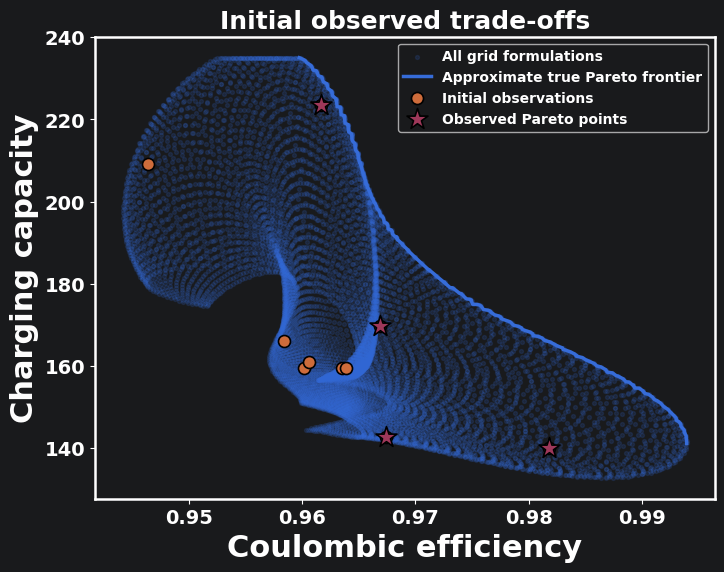

In [5]:
set_seed(seed)

n_init = 10

train_X_init = draw_sobol_samples(
    bounds=bounds,
    n=1,
    q=n_init,
).squeeze(0)

train_Y_init = electrolyte_objectives(train_X_init)

init_df = pd.DataFrame({
    "salt_concentration": train_X_init[:, 0].detach().cpu().numpy(),
    "additive_fraction": train_X_init[:, 1].detach().cpu().numpy(),
    "coulombic_efficiency": train_Y_init[:, 0].detach().cpu().numpy(),
    "charging_capacity": train_Y_init[:, 1].detach().cpu().numpy(),
})

display(init_df)

observed_pareto_mask = is_non_dominated(train_Y_init)
observed_pareto_X = train_X_init[observed_pareto_mask]
observed_pareto_Y = train_Y_init[observed_pareto_mask]

print("Initial observations:", train_X_init.shape[0])
print("Initial observed Pareto points:", observed_pareto_Y.shape[0])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    grid_Y[:, 0],
    grid_Y[:, 1],
    s=8,
    alpha=0.15,
    label="All grid formulations",
)

ax.plot(
    true_pareto_Y[:, 0],
    true_pareto_Y[:, 1],
    lw=2.5,
    label="Approximate true Pareto frontier",
)

ax.scatter(
    train_Y_init[:, 0],
    train_Y_init[:, 1],
    s=75,
    edgecolor="black",
    lw=1.2,
    label="Initial observations",
)

ax.scatter(
    observed_pareto_Y[:, 0],
    observed_pareto_Y[:, 1],
    s=250,
    marker="*",
    edgecolor="black",
    lw=1.2,
    label="Observed Pareto points",
)

ax.set_title("Initial observed trade-offs", fontsize=18, fontweight="bold")
ax.set_xlabel("Coulombic efficiency", fontsize=22, fontweight="bold")
ax.set_ylabel("Charging capacity", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 5. Hypervolume and the reference point

We now introduce the scalar progress metric used in this multi-objective BO tutorial: **hypervolume**.

In single-objective optimisation, progress is easy to summarise. If we are maximising one function, we can track the best value found so far.

In multi-objective optimisation, that is no longer enough.

There is usually no single best value, because the optimiser is trying to improve a set of trade-offs rather than one scalar objective.

So instead of measuring progress by one best objective value, we measure how good the current Pareto frontier is as a whole.

That is what hypervolume is for.

---

### What hypervolume means

For this notebook, both objectives are being maximised:

$$
\max_x \left(f_{\text{eff}}(x), f_{\text{cap}}(x)\right).
$$

A Pareto point dominates all objective-space points that are worse than it in both objectives.

In two dimensions, this dominated region can be visualised as an area.

For example, if a formulation has objective values

$$
(0.97, 200),
$$

and the reference point is

$$
(0.88, 115),
$$

then that formulation dominates the rectangle between those two corners in objective space.

The **hypervolume** is the total area dominated by the current Pareto set, measured relative to the reference point.

So larger hypervolume means that the observed Pareto frontier is better, either because it has moved toward higher objective values or because it covers a broader set of useful trade-offs.

---

### Why we need a reference point

Hypervolume is always measured relative to a **reference point**.

The reference point defines the lower-left baseline of the dominated region for a two-objective maximisation problem.

In this tutorial, we use

$$
\text{reference point} = (0.88, 115.0).
$$

This choice is deliberate.

From the earlier grid evaluation, the synthetic objective values are approximately above this region. So the reference point is chosen to be worse than the objective values we consider useful:

- $0.88$ is below the relevant Coulombic-efficiency range,
- $115.0$ is below the relevant charging-capacity range.

This places the reference point in the lower-left corner of the objective-space plot.

Because both objectives are maximised, points above and to the right of this reference point contribute positive dominated hypervolume.

---

### Why the reference point matters

The reference point is not just a plotting detail.

It affects both:

- the numerical value of the hypervolume,
- and the behaviour of **qEHVI** later in the notebook.

This is because qEHVI selects candidates by expected hypervolume improvement:

$$
\mathbb{E}[\Delta \text{Hypervolume}].
$$

So changing the reference point changes what kind of improvement is considered valuable.

A very permissive reference point measures broad progress over a large objective-space region. A stricter reference point focuses improvement on a higher-performance region.

In real experimental applications, the reference point should usually reflect minimum acceptable performance or the region of objective space that is scientifically meaningful.

---

### What the helper functions do

The function `get_pareto_Y(Y)` identifies the observed Pareto points from a set of objective values and sorts them by Coulombic efficiency for cleaner plotting.

The function `compute_hypervolume(Y, ref_point)` then:

1. extracts the observed Pareto points,
2. computes the region they dominate relative to the reference point,
3. returns the resulting dominated hypervolume as a scalar.

This scalar will be used later to track BO progress over time.

---

### What the figure shows

The plot shows:

- the approximate true Pareto frontier,
- the initial observed formulations,
- the initial observed Pareto points,
- and the hypervolume reference point.

The dashed lines mark the reference values for the two objectives.

The initial observed Pareto points dominate a region above and to the right of the reference point. That dominated region is summarised numerically by the initial hypervolume.

As BO proceeds, the goal is to discover new formulations that expand this dominated region.

---

### Key takeaway

Hypervolume turns a Pareto frontier into a scalar progress metric.

It does not replace the scientific meaning of the two objectives. Instead, it provides a way to measure whether the current set of trade-offs is improving.

The reference point defines the baseline for this measurement, so it must be chosen carefully. In this tutorial, $(0.88, 115.0)$ is used as a deliberately weak baseline below the useful objective region.

Reference point: [0.88, 115.0]


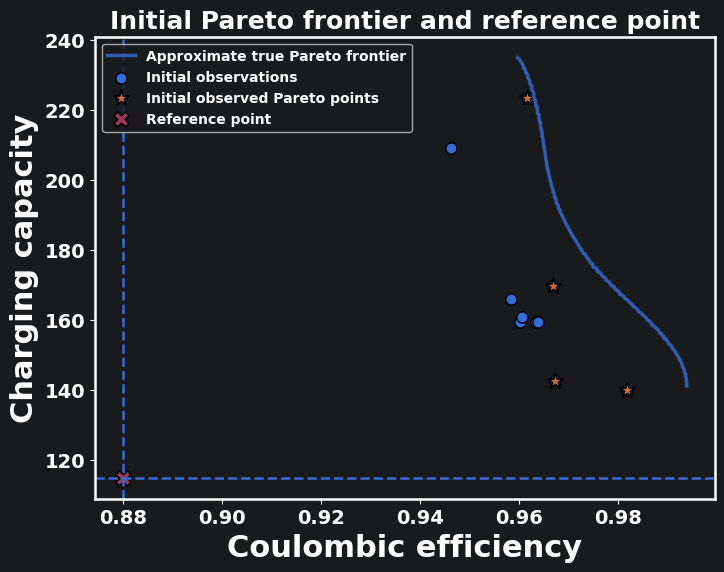

In [6]:
ref_point = torch.tensor([0.88, 115.0], dtype=torch.double)

def get_pareto_Y(Y):
    pareto_mask = is_non_dominated(Y)
    pareto_Y = Y[pareto_mask]
    sort_idx = torch.argsort(pareto_Y[:, 0])
    return pareto_Y[sort_idx], pareto_mask

def compute_hypervolume(Y, ref_point=ref_point):
    pareto_Y, _ = get_pareto_Y(Y)

    if pareto_Y.numel() == 0:
        return 0.0

    hv = Hypervolume(ref_point=ref_point)
    return float(hv.compute(pareto_Y))

initial_pareto_Y, initial_pareto_mask = get_pareto_Y(train_Y_init)
initial_hv = compute_hypervolume(train_Y_init, ref_point=ref_point)

print("Reference point:", ref_point.tolist())

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    true_pareto_Y[:, 0],
    true_pareto_Y[:, 1],
    lw=2.5,
    alpha=0.8,
    label="Approximate true Pareto frontier",
)

ax.scatter(
    train_Y_init[:, 0],
    train_Y_init[:, 1],
    s=65,
    edgecolor="black",
    lw=1.0,
    label="Initial observations",
)

ax.scatter(
    initial_pareto_Y[:, 0],
    initial_pareto_Y[:, 1],
    s=130,
    marker="*",
    edgecolor="black",
    lw=1.2,
    label="Initial observed Pareto points",
)

ax.scatter(
    ref_point[0],
    ref_point[1],
    s=120,
    marker="X",
    edgecolor="black",
    lw=1.2,
    label="Reference point",
)

ax.axvline(float(ref_point[0]), linestyle="--", lw=1.8)
ax.axhline(float(ref_point[1]), linestyle="--", lw=1.8)

ax.set_title("Initial Pareto frontier and reference point", fontsize=18, fontweight="bold")
ax.set_xlabel("Coulombic efficiency", fontsize=22, fontweight="bold")
ax.set_ylabel("Charging capacity", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 6. Fitting a multi-objective GP and proposing a qEHVI candidate

We now define the two core functions needed for the multi-objective BO loop.

The first function, `fit_multi_objective_gp(...)`, fits the surrogate model.

The second function, `propose_qehvi_candidate(...)`, uses that surrogate model to construct and optimise the multi-objective acquisition function.

These two steps are deliberately separated because they represent two different parts of the BO workflow:

1. **modelling what we currently know**,
2. **deciding where to evaluate next**.

This separation makes the later BO loop much easier to read.

---

### Why `fit_multi_objective_gp(...)` is separate

The function `fit_multi_objective_gp(...)` takes the current input-output data and fits a surrogate model.

In a standard single-objective BO loop, we usually fit one GP:

$$
x \mapsto f(x).
$$

Here, however, the output has two objectives:

$$
x \mapsto \left(f_{\text{eff}}(x), f_{\text{cap}}(x)\right).
$$

So instead of fitting one GP, we fit one GP per objective.

The loop

`for obj_idx in range(train_Y.shape[-1]):`

goes through each objective column in `train_Y`.

For each objective, it creates a separate `SingleTaskGP`.

So in this notebook:

- one GP models Coulombic efficiency,
- one GP models charging capacity.

These independent models are then combined using `ModelListGP`.

This means the final surrogate is a multi-output model, but it is built from separate single-output GPs.

That is a clean and practical BoTorch pattern for introductory multi-objective BO.

---

### Why one GP per objective is used

The two objectives have different numerical scales and different landscape shapes.

Coulombic efficiency varies over a relatively narrow range, while charging capacity varies over a much larger range.

By fitting one GP per objective and applying `Standardize(m=1)` separately, each objective is modelled on its own standardised scale.

This avoids forcing both objectives into one scalar target too early.

That is important because multi-objective BO should preserve the trade-off structure between objectives rather than collapse them immediately into a weighted score.

---

### Why `propose_qehvi_candidate(...)` is separate

Once the model has been fitted, the next question is:

> where should we evaluate next?

In single-objective BO, this step might use an acquisition function such as UCB, PI, or LogEI.

Those acquisition functions ask questions like:

> which point is expected to improve the current best scalar value?

But in multi-objective BO, there is no single current best scalar value.

There is a current **observed Pareto set**.

So the acquisition function needs to ask a different question:

> which point is expected to improve the Pareto frontier the most?

That is what `qExpectedHypervolumeImprovement`, or qEHVI, is designed to do.

---

### What `NondominatedPartitioning` does

The line

`partitioning = NondominatedPartitioning(ref_point=ref_point, Y=train_Y)`

constructs a decomposition of the current non-dominated objective space.

Conceptually, it tells qEHVI what region is already dominated by the current observed Pareto frontier.

This is needed because qEHVI computes expected **additional** dominated hypervolume.

So it needs to know:

- what the current Pareto set is,
- what region of objective space it already dominates,
- and where new candidates could expand that dominated region.

---

### What qEHVI is optimising

qEHVI selects candidates by maximising expected hypervolume improvement:

$$
\mathbb{E}[\Delta \text{Hypervolume}].
$$

This is the multi-objective analogue of expected improvement.

In single-objective BO, expected improvement asks:

$$
\mathbb{E}\left[\max(f(x) - f_{\text{best}}, 0)\right].
$$

In multi-objective BO, there is no single $f_{\text{best}}$.

So qEHVI instead asks:

> how much do we expect this candidate to expand the dominated hypervolume of the current Pareto frontier?

That is why the acquisition function needs both:

- the fitted multi-objective model,
- and the current observed objective values `train_Y`.

The model provides uncertainty about candidate outcomes.

The current `train_Y` defines the existing Pareto frontier and hypervolume baseline.

---

### Difference from a standard 1D BO loop

Compared with a standard 1D BO loop, several things change.

In a standard single-objective loop, the workflow is usually:

1. fit one GP to one scalar target,
2. define one acquisition function using the current best value,
3. optimise the acquisition function,
4. evaluate the next candidate,
5. update the dataset.

Here, the workflow becomes:

1. fit one GP per objective,
2. combine them into a `ModelListGP`,
3. identify the current non-dominated objective structure,
4. define qEHVI using the reference point and Pareto partitioning,
5. optimise qEHVI,
6. evaluate the next candidate on all objectives,
7. update the multi-objective dataset.

So the main conceptual difference is this:

> single-objective BO improves one best value, while multi-objective BO improves a frontier of trade-offs.

---

### Interpreting the candidate

The printed candidate is the next electrolyte formulation proposed by qEHVI.

It is a point in the two-dimensional input space:

- salt concentration,
- additive fraction.

The printed objective values show what this candidate would achieve under the synthetic objective.

In this example, qEHVI proposes a formulation with very high charging capacity.

That makes sense: early in the run, the algorithm is trying to expand the observed Pareto frontier by finding points that may improve the currently dominated hypervolume.

It is not simply trying to maximise one objective alone.

It is trying to find a point that is useful for improving the trade-off frontier.

---

### Key takeaway

This cell defines the two reusable components of the multi-objective BO loop.

`fit_multi_objective_gp(...)` models each objective separately and combines the models into a multi-output surrogate.

`propose_qehvi_candidate(...)` then uses that surrogate to select the next formulation by expected hypervolume improvement.

Compared with standard single-objective BO, the key change is that candidate selection is no longer based on improvement over one best value. It is based on expected improvement of the Pareto frontier.

In [7]:
def fit_multi_objective_gp(train_X, train_Y):
    models = []

    for obj_idx in range(train_Y.shape[-1]):
        gp = SingleTaskGP(
            train_X=train_X,
            train_Y=train_Y[:, obj_idx:obj_idx + 1],
            input_transform=Normalize(d=train_X.shape[-1]),
            outcome_transform=Standardize(m=1),
        )
        models.append(gp)

    model = ModelListGP(*models)
    mll = SumMarginalLogLikelihood(model.likelihood, model)

    fit_gpytorch_mll(mll)
    model.eval()

    return model


def propose_qehvi_candidate(
    model,
    train_Y,
    bounds,
    ref_point=ref_point,
    num_restarts=10,
    raw_samples=128,
    sampler_samples=128,
):
    partitioning = NondominatedPartitioning(
        ref_point=ref_point,
        Y=train_Y,
    )

    sampler = SobolQMCNormalSampler(
        sample_shape=torch.Size([sampler_samples])
    )

    acq = qExpectedHypervolumeImprovement(
        model=model,
        ref_point=ref_point.tolist(),
        partitioning=partitioning,
        sampler=sampler,
    )

    candidate, acq_value = optimize_acqf(
        acq_function=acq,
        bounds=bounds,
        q=1,
        num_restarts=num_restarts,
        raw_samples=raw_samples,
    )

    return candidate.detach(), float(acq_value)


mo_model_init = fit_multi_objective_gp(train_X_init, train_Y_init)

qehvi_candidate, qehvi_value = propose_qehvi_candidate(
    model=mo_model_init,
    train_Y=train_Y_init,
    bounds=bounds,
    ref_point=ref_point,
)

qehvi_candidate_Y = electrolyte_objectives(qehvi_candidate)

print("Initial multi-objective GP fitted with", train_Y_init.shape[-1], "outputs")
print("qEHVI candidate:", qehvi_candidate.view(-1).tolist())
print("qEHVI acquisition value:", qehvi_value)
print("Objective values at qEHVI candidate:")
print(qehvi_candidate_Y.detach().cpu().numpy())

Initial multi-objective GP fitted with 2 outputs
qEHVI candidate: [0.7174244689769635, 0.5894203601318502]
qEHVI acquisition value: 0.5267414177302879
Objective values at qEHVI candidate:
[[  0.9588377 235.       ]]


## 7. Running the qEHVI multi-objective BO loop

We now build the full qEHVI Bayesian optimisation loop.

Up to this point, we have defined the key ingredients separately:

- the synthetic electrolyte objective,
- the initial Sobol design,
- the observed Pareto set,
- the hypervolume reference point,
- the multi-objective GP model,
- and the qEHVI acquisition function.

This cell puts those pieces together into a complete sequential BO workflow.

---

### Overall structure of the BO loop

The function `run_qehvi_bo_loop(...)` implements the standard sequential BO pattern, but adapted to the multi-objective setting.

At each BO step, the workflow is:

1. fit a multi-objective GP surrogate to the current data,
2. construct a qEHVI acquisition function from the current observed objectives,
3. optimise qEHVI to propose the next candidate formulation,
4. evaluate both objectives at that candidate,
5. append the new data point to the dataset,
6. compute diagnostics such as hypervolume and number of Pareto points,
7. repeat.

So the loop still has the familiar BO structure:

$$
\text{fit model} \rightarrow \text{choose candidate} \rightarrow \text{evaluate} \rightarrow \text{update data}.
$$

What changes is the criterion used to choose the candidate.

Instead of improving one scalar best value, qEHVI tries to improve the current Pareto frontier.

---

### Initialising the BO state

At the start of the function, the initial data are copied:

`train_X = train_X_init.clone()`

`train_Y = train_Y_init.clone()`

This is useful because the BO loop will repeatedly append new observations. Cloning avoids accidentally modifying the original initial dataset.

The list `history` is then used to store the state of the optimisation at every step.

Before any new BO candidate is proposed, the code records the initial state at `step = 0`.

This initial entry stores:

- the current input data,
- the current objective values,
- the current dominated hypervolume,
- the number of observations,
- and the number of observed Pareto points.

This gives a baseline against which later BO progress can be compared.

---

### Fitting the model at each step

Inside the loop, the first operation is:

`model = fit_multi_objective_gp(train_X, train_Y)`

This refits the multi-objective GP using all observations collected so far.

Because this is a two-objective problem, the model contains:

- one GP for Coulombic efficiency,
- one GP for charging capacity.

The model is refit at every step because the dataset changes after each new evaluation.

This is the usual sequential BO structure: each new observation updates the surrogate, and the updated surrogate changes the next acquisition decision.

---

### Proposing the next candidate with qEHVI

After fitting the model, the code proposes a new candidate using:

`propose_qehvi_candidate(...)`

This function constructs and optimises `qExpectedHypervolumeImprovement`.

The acquisition function uses:

- the fitted multi-objective GP,
- the current objective values `train_Y`,
- the hypervolume reference point,
- and the current Pareto partitioning.

Conceptually, qEHVI asks:

> which candidate is expected to increase the dominated hypervolume of the current Pareto frontier the most?

This is the key multi-objective change.

In a single-objective BO loop, the candidate is usually chosen because it may improve the best scalar value.

Here, the candidate is chosen because it may improve the trade-off frontier.

---

### Evaluating the candidate

Once the candidate is selected, the synthetic objective is evaluated:

`Y_new = electrolyte_objectives(candidate)`

This returns both objective values at the proposed formulation:

- Coulombic efficiency,
- charging capacity.

In a real experiment, this would correspond to preparing and testing a new electrolyte formulation, then measuring both performance metrics.

In this synthetic notebook, the objective values are available immediately from the function.

---

### Updating the dataset

After evaluation, the new candidate and its objective values are appended to the training data:

`train_X = torch.cat([train_X, candidate], dim=0)`

`train_Y = torch.cat([train_Y, Y_new], dim=0)`

This means the next BO step will fit the GP to a larger dataset.

The optimisation therefore becomes sequential and adaptive: each new experiment affects the model, and the model affects the next experiment.

---

### Recording diagnostics

After each step, the loop appends a dictionary to `history`.

This stores:

- the BO step,
- the current training inputs,
- the current objective values,
- the newly proposed candidate,
- the objective values at that candidate,
- the qEHVI acquisition value,
- the current hypervolume,
- the total number of observations,
- and the number of observed Pareto points.

The most important diagnostic here is `hypervolume`.

Since this is a multi-objective problem, there is no single best objective value to track.

Instead, hypervolume measures how much objective-space area is dominated by the current observed Pareto set relative to the reference point.

So if the BO loop is working well, we generally expect the hypervolume to increase over time.

---

### Final model

After the loop finishes, the function fits one final multi-objective GP to the full dataset:

`final_model = fit_multi_objective_gp(train_X, train_Y)`

This final model represents everything learned after the initial observations plus the BO-guided evaluations.

The function returns:

- the full optimisation history,
- the final input data,
- the final objective values,
- and the final fitted model.

This keeps the result flexible for later analysis and plotting.

---

### What the printed output means

The output

`Final qEHVI observations: 26`

means that the run contains:

$$
10 + 16 = 26
$$

total observations.

The first 10 came from the initial Sobol design, and the next 16 were selected by qEHVI.

The output

`Final qEHVI Pareto points: 11`

means that, among the 26 evaluated formulations, 11 are non-dominated relative to the other observed formulations.

These are the final observed Pareto points discovered by the qEHVI workflow.

---

### Key takeaway

This cell constructs the full qEHVI multi-objective BO loop.

The loop repeatedly fits a multi-objective GP, proposes a new candidate by expected hypervolume improvement, evaluates both objectives, and updates the observed Pareto set.

Compared with a standard single-objective BO loop, the central difference is that progress is tracked by improvement of the Pareto frontier rather than improvement of one best scalar value.

In [8]:
def run_qehvi_bo_loop(
    train_X_init,
    train_Y_init,
    n_steps,
    ref_point=ref_point,
    num_restarts=10,
    raw_samples=128,
    sampler_samples=128,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    history.append({
        "step": 0,
        "train_X": train_X.clone(),
        "train_Y": train_Y.clone(),
        "hypervolume": compute_hypervolume(train_Y, ref_point=ref_point),
        "n_observations": train_X.shape[0],
        "n_pareto": int(is_non_dominated(train_Y).sum().item()),
    })

    for step in range(1, n_steps + 1):
        model = fit_multi_objective_gp(train_X, train_Y)

        candidate, acq_value = propose_qehvi_candidate(
            model=model,
            train_Y=train_Y,
            bounds=bounds,
            ref_point=ref_point,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
            sampler_samples=sampler_samples,
        )

        Y_new = electrolyte_objectives(candidate)

        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, Y_new], dim=0)

        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "candidate": candidate.clone(),
            "candidate_Y": Y_new.clone(),
            "acq_value": acq_value,
            "hypervolume": compute_hypervolume(train_Y, ref_point=ref_point),
            "n_observations": train_X.shape[0],
            "n_pareto": int(is_non_dominated(train_Y).sum().item()),
        })

    final_model = fit_multi_objective_gp(train_X, train_Y)

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
        "model_final": final_model,
    }


set_seed(seed)

n_bo_steps = 16

qehvi_result = run_qehvi_bo_loop(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    n_steps=n_bo_steps,
    ref_point=ref_point,
    num_restarts=10,
    raw_samples=128,
    sampler_samples=128,
)

print("Final qEHVI observations:", qehvi_result["train_X_final"].shape[0])
print("Final qEHVI Pareto points:", qehvi_result["history"][-1]["n_pareto"])

Final qEHVI observations: 26
Final qEHVI Pareto points: 11


## 8. Random search baseline for comparison

We now introduce a random-search baseline.

This is not because random search is expected to be a sophisticated optimiser. It is included because a BO result is difficult to interpret without a reference point.

If qEHVI improves the Pareto frontier, we need to know whether that improvement is genuinely due to the acquisition-driven BO logic, or whether a similar result would have happened simply by sampling more points from the design space.

That is why this baseline is necessary.

---

### Why a benchmark is needed

A BO loop will usually improve as it collects more evaluations, even if the candidate selection rule is not very intelligent.

This is especially true in synthetic examples where the search space is small and every additional point has some chance of improving the observed Pareto set.

So if we only plot qEHVI by itself, we might incorrectly conclude that the method is working well just because the hypervolume increases over time.

But the real question is stronger:

> does qEHVI improve the Pareto frontier more efficiently than uninformed sampling?

The random baseline helps answer that question.

---

### What the random baseline does

The function `run_random_search_baseline(...)` starts from exactly the same initial dataset as the qEHVI run.

It then adds the same number of extra evaluations, but chooses those new candidates using Sobol sampling rather than an acquisition function.

So the comparison is fair in terms of evaluation budget:

- qEHVI starts from the same initial observations,
- random search starts from the same initial observations,
- both methods add `n_bo_steps` new formulations,
- and both methods end with the same total number of observations.

The difference is only in how the new candidates are chosen.

qEHVI uses a model-based acquisition function designed to improve hypervolume.

Random search samples new points without using the surrogate model, uncertainty, Pareto structure, or hypervolume information.

---

### What is recorded in `history`

As in the qEHVI loop, the random baseline records the state of the search after each step.

For each step, it stores:

- the current input data,
- the current objective values,
- the current hypervolume,
- the number of observations,
- and the number of observed Pareto points.

This means that random search can be compared to qEHVI using the same diagnostics.

That is important: a useful benchmark should be evaluated in the same way as the method being tested.

---

### Why Sobol sampling is used

The random candidates are generated using Sobol sampling rather than ordinary independent uniform random sampling.

Sobol points are space-filling and tend to cover the input domain more evenly.

So this is a reasonably strong random baseline: it is not purely chaotic sampling, but an uninformed space-filling strategy.

This makes the comparison more meaningful.

If qEHVI outperforms this baseline, then it is not merely beating a very weak random method. It is beating a sensible non-adaptive exploration strategy.

---

### What the printed output means

The output confirms that random search uses the same total number of observations as qEHVI.

In this run, both methods end with 26 observations:

$$
10 + 16 = 26.
$$

The random baseline finds fewer final Pareto points than qEHVI in this run.

This suggests that qEHVI is using the evaluation budget more effectively to expand the observed trade-off frontier.

However, the stronger comparison will come from the next diagnostic plot, where we compare hypervolume progress directly.

---

### Key takeaway

This cell introduces random Sobol search as a benchmark for qEHVI.

The purpose is to test whether multi-objective BO is doing more than simply collecting additional samples.

By comparing qEHVI against a same-budget random baseline, we can evaluate whether the acquisition function is actually helping the optimiser improve the Pareto frontier more efficiently.

In [9]:
def run_random_search_baseline(
    train_X_init,
    train_Y_init,
    n_steps,
    ref_point=ref_point,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    history.append({
        "step": 0,
        "train_X": train_X.clone(),
        "train_Y": train_Y.clone(),
        "hypervolume": compute_hypervolume(train_Y, ref_point=ref_point),
        "n_observations": train_X.shape[0],
        "n_pareto": int(is_non_dominated(train_Y).sum().item()),
    })

    random_X = draw_sobol_samples(
        bounds=bounds,
        n=1,
        q=n_steps,
    ).squeeze(0)

    for step in range(1, n_steps + 1):
        candidate = random_X[step - 1:step]
        Y_new = electrolyte_objectives(candidate)

        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, Y_new], dim=0)

        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "candidate": candidate.clone(),
            "candidate_Y": Y_new.clone(),
            "hypervolume": compute_hypervolume(train_Y, ref_point=ref_point),
            "n_observations": train_X.shape[0],
            "n_pareto": int(is_non_dominated(train_Y).sum().item()),
        })

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
    }


set_seed(seed + 100)

random_result = run_random_search_baseline(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    n_steps=n_bo_steps,
    ref_point=ref_point,
)

print("Final random observations:", random_result["train_X_final"].shape[0])
print("Final random Pareto points:", random_result["history"][-1]["n_pareto"])

Final random observations: 26
Final random Pareto points: 6


## 9. Comparing hypervolume progress

We now compare how quickly qEHVI and random Sobol search improve the observed Pareto frontier.

The diagnostic used here is **dominated hypervolume**.

This is the natural progress metric for a multi-objective BO problem because there is no single best scalar objective value to track.

Instead, we ask:

> how much objective-space area is dominated by the current observed Pareto frontier?

A larger hypervolume means that the observed trade-off frontier has improved.

---

### What is being compared

Both methods start from exactly the same initial dataset.

After that, they differ only in how they choose new points:

- **qEHVI** chooses candidates by expected hypervolume improvement,
- **random Sobol** chooses new candidates using space-filling sampling without looking at the surrogate model or Pareto structure.

So this is a same-budget comparison.

Both methods have the same number of BO steps and the same total number of evaluations.

The difference is whether the new evaluations are chosen adaptively using multi-objective BO or non-adaptively using a random space-filling baseline.

---

### What the dashed line means

The dashed horizontal line is

`approx_best_hv = compute_hypervolume(grid_Y, ref_point=ref_point)`.

This is the hypervolume obtained by using all objective values on the dense synthetic grid.

Because this tutorial uses a synthetic objective, we can evaluate the objective densely across the whole input space and estimate the approximate best achievable Pareto frontier on that grid.

That gives an approximate upper benchmark for the plot.

This would not be available in a real experiment.

In a real electrolyte optimisation campaign, we would not know the objective values everywhere in advance. Here, it is included only as a diagnostic reference so that we can judge how close the BO run gets to the best frontier available on the dense grid.

---

### Interpreting the figure

The qEHVI curve rises quickly in the early BO steps.

This means that qEHVI rapidly finds candidates that expand the dominated hypervolume of the observed Pareto frontier.

That is exactly the behaviour it is designed for: it uses the GP surrogate and uncertainty estimates to choose evaluations that are likely to improve the trade-off frontier.

The random Sobol curve also improves, but much more slowly and then plateaus.

This makes sense. Random search can still find useful formulations by chance, especially in a low-dimensional synthetic problem, but it is not explicitly targeting hypervolume improvement.

The gap between qEHVI and random search therefore indicates that qEHVI is using the evaluation budget more efficiently.

---

### Why hypervolume is monotonic here

The hypervolume curves should be non-decreasing.

Adding a new evaluated point cannot make the observed Pareto set worse, because the previous Pareto points are still available.

A new point can either:

- expand the dominated region, increasing hypervolume,
- or fail to improve the frontier, leaving hypervolume unchanged.

So plateaus in the curve mean that the new evaluation did not expand the observed Pareto frontier.

Sharp jumps mean that the new evaluation contributed a meaningful improvement to the frontier.

---

### Key takeaway

This figure shows that qEHVI improves the Pareto frontier much more efficiently than random Sobol search in this synthetic example.

The dashed dense-grid hypervolume line provides an approximate upper benchmark.

qEHVI moves close to this benchmark within a small number of evaluations, while random search remains substantially lower.

This supports the main point of the tutorial:

> multi-objective BO is not just collecting more samples; it is actively choosing experiments that are expected to improve the trade-off frontier.

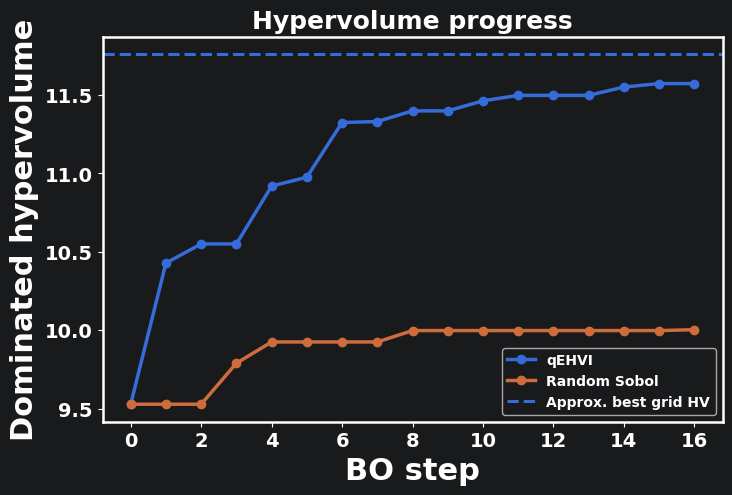

In [10]:
qehvi_steps = [h["step"] for h in qehvi_result["history"]]
qehvi_hv = [h["hypervolume"] for h in qehvi_result["history"]]

random_steps = [h["step"] for h in random_result["history"]]
random_hv = [h["hypervolume"] for h in random_result["history"]]

approx_best_hv = compute_hypervolume(grid_Y, ref_point=ref_point)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    qehvi_steps,
    qehvi_hv,
    "-o",
    lw=2.5,
    markersize=6,
    label="qEHVI",
)

ax.plot(
    random_steps,
    random_hv,
    "-o",
    lw=2.5,
    markersize=6,
    label="Random Sobol",
)

ax.axhline(
    approx_best_hv,
    linestyle="--",
    lw=2.2,
    label="Approx. best grid HV",
)

ax.set_title("Hypervolume progress", fontsize=18, fontweight="bold")
ax.set_xlabel("BO step", fontsize=22, fontweight="bold")
ax.set_ylabel("Dominated hypervolume", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 10. Final observed Pareto frontier comparison

We now compare the final observed Pareto frontiers produced by qEHVI and by random Sobol search.

The previous plot showed the same story through a scalar diagnostic: hypervolume.

This figure shows the result directly in objective space.

Each panel contains:

- the approximate true Pareto frontier from the dense grid,
- all observations collected by the method,
- the observed Pareto points among those observations,
- and the reference point used for hypervolume calculation.

This makes it easier to see not only how much hypervolume each method achieved, but also **where** the useful trade-off points were found.

---

### What the qEHVI panel shows

The qEHVI panel shows that the final observed Pareto points span a large part of the approximate true Pareto frontier.

This is important.

qEHVI is not only finding one good formulation. It is finding several formulations that lie along different parts of the trade-off boundary.

In this run, the qEHVI Pareto points cover regions including:

- high-capacity formulations with lower Coulombic efficiency,
- intermediate trade-off formulations,
- and high-efficiency formulations with lower capacity.

That behaviour is exactly what we want from a multi-objective BO method.

The aim is not to collapse the problem into one best point immediately. The aim is to learn a useful set of trade-offs that a later decision rule can choose from.

So the qEHVI result shows a strong multi-objective behaviour:

> qEHVI actively expands the observed frontier so that the final Pareto set spans the real trade-off curve.

---

### Why qEHVI behaves this way

qEHVI selects candidates by expected hypervolume improvement.

This means it rewards points that are expected to expand the region dominated by the current Pareto set.

A candidate can increase hypervolume in different ways.

It might:

- improve the high-capacity end of the frontier,
- improve the high-efficiency end of the frontier,
- fill a gap in the middle of the trade-off curve,
- or push the whole observed frontier closer to the true frontier.

So qEHVI naturally encourages a spread of useful Pareto points, rather than repeatedly selecting candidates near only one objective optimum.

That is why the observed qEHVI Pareto points are distributed along the frontier instead of clustering around a single formulation.

---

### What the random-search panel shows

The random Sobol baseline also finds some non-dominated points.

That is expected.

Random exploration can sometimes land near useful regions, especially in a two-dimensional synthetic problem.

However, the random observed Pareto points do not cover the true frontier as well as qEHVI.

They are fewer in number and sit further from the approximate true Pareto boundary in important regions.

This explains why the random baseline has lower final hypervolume.

It has found some good trade-offs, but it has not expanded the observed frontier as efficiently.

---

### Interpreting the comparison table

The table summarises the same comparison numerically.

Both methods use the same total number of observations.

In this run, qEHVI and random Sobol both end with 26 evaluated formulations.

However, qEHVI achieves:

- a larger final hypervolume,
- more final observed Pareto points,
- and a frontier that visually tracks the approximate true Pareto frontier much more closely.

So the improvement is not simply because qEHVI evaluated more points.

It used the same evaluation budget more effectively.

---

### Key takeaway

This figure shows the qualitative reason behind the hypervolume result.

qEHVI improves the observed Pareto frontier by placing useful evaluations along the true trade-off boundary.

Random Sobol search can still find some non-dominated points, but it does not deliberately target frontier expansion.

So the main conclusion is:

> qEHVI does not merely seek one high-performing formulation; it learns a broader set of Pareto-optimal trade-offs that spans the real frontier more effectively than random exploration.

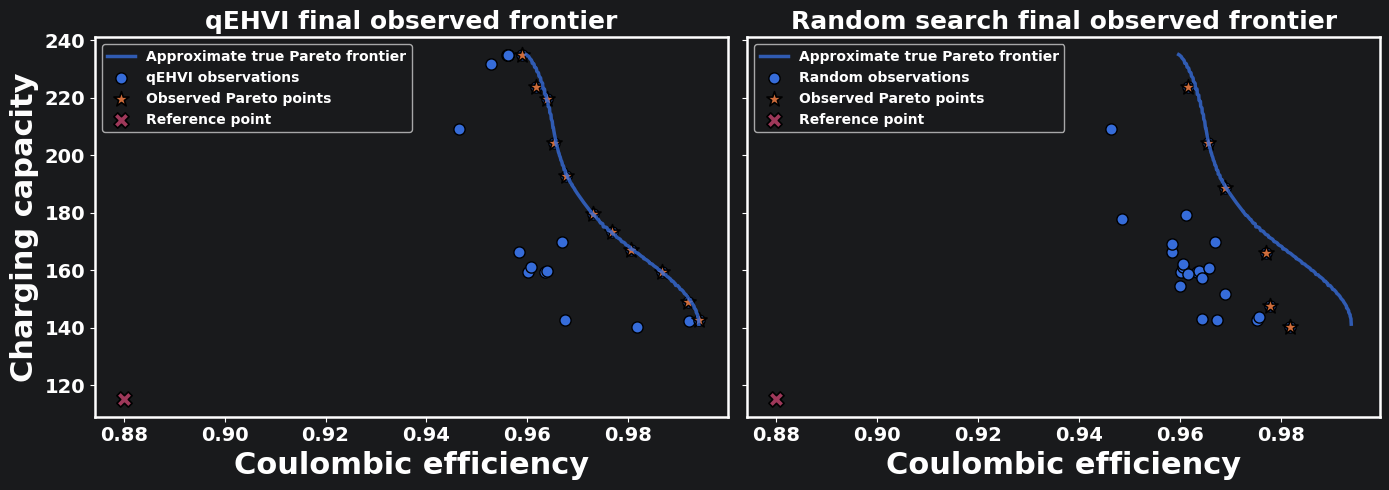

,method,final_hypervolume,n_final_pareto_points,n_total_observations
0,qEHVI,11.572747,11,26
1,Random Sobol,10.003796,6,26


In [11]:
qehvi_final_Y = qehvi_result["train_Y_final"]
random_final_Y = random_result["train_Y_final"]

qehvi_pareto_Y, qehvi_pareto_mask = get_pareto_Y(qehvi_final_Y)
random_pareto_Y, random_pareto_mask = get_pareto_Y(random_final_Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

axes[0].plot(
    true_pareto_Y[:, 0],
    true_pareto_Y[:, 1],
    lw=2.5,
    alpha=0.8,
    label="Approximate true Pareto frontier",
)

axes[0].scatter(
    qehvi_final_Y[:, 0],
    qehvi_final_Y[:, 1],
    s=65,
    edgecolor="black",
    lw=1.0,
    label="qEHVI observations",
)

axes[0].scatter(
    qehvi_pareto_Y[:, 0],
    qehvi_pareto_Y[:, 1],
    s=130,
    marker="*",
    edgecolor="black",
    lw=1.2,
    label="Observed Pareto points",
)

axes[0].scatter(
    ref_point[0],
    ref_point[1],
    s=120,
    marker="X",
    edgecolor="black",
    lw=1.2,
    label="Reference point",
)

axes[0].set_title("qEHVI final observed frontier", fontsize=18, fontweight="bold")
axes[0].set_xlabel("Coulombic efficiency", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Charging capacity", fontsize=22, fontweight="bold")
axes[0].legend(prop={"size": 10, "weight": "bold"})
style_ax(axes[0])

axes[1].plot(
    true_pareto_Y[:, 0],
    true_pareto_Y[:, 1],
    lw=2.5,
    alpha=0.8,
    label="Approximate true Pareto frontier",
)

axes[1].scatter(
    random_final_Y[:, 0],
    random_final_Y[:, 1],
    s=65,
    edgecolor="black",
    lw=1.0,
    label="Random observations",
)

axes[1].scatter(
    random_pareto_Y[:, 0],
    random_pareto_Y[:, 1],
    s=130,
    marker="*",
    edgecolor="black",
    lw=1.2,
    label="Observed Pareto points",
)

axes[1].scatter(
    ref_point[0],
    ref_point[1],
    s=120,
    marker="X",
    edgecolor="black",
    lw=1.2,
    label="Reference point",
)

axes[1].set_title("Random search final observed frontier", fontsize=18, fontweight="bold")
axes[1].set_xlabel("Coulombic efficiency", fontsize=22, fontweight="bold")
axes[1].legend(prop={"size": 10, "weight": "bold"})
style_ax(axes[1])

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    "method": ["qEHVI", "Random Sobol"],
    "final_hypervolume": [
        qehvi_result["history"][-1]["hypervolume"],
        random_result["history"][-1]["hypervolume"],
    ],
    "n_final_pareto_points": [
        int(is_non_dominated(qehvi_final_Y).sum().item()),
        int(is_non_dominated(random_final_Y).sum().item()),
    ],
    "n_total_observations": [
        qehvi_final_Y.shape[0],
        random_final_Y.shape[0],
    ],
})

display(comparison_df)

## 11. Locating the Pareto formulations in input space

So far, most of the analysis has been done in **objective space**.

That was useful because Pareto optimality is defined by objective values:

- Coulombic efficiency,
- Charging capacity.

However, an experimentalist eventually needs to know the actual formulation conditions that produced those trade-offs.

So this cell maps the final qEHVI Pareto points back into **input space**:

- Salt concentration,
- Additive fraction.

This answers a different question:

> where in the formulation space are the best trade-off experiments located?

---

### What the figure shows

The circular markers show all formulations evaluated by qEHVI.

The star markers show the final Pareto formulations among those evaluations.

These are the formulations that are non-dominated in objective space: none of the other evaluated formulations is better in both Coulombic efficiency and charging capacity.

The important point is that the Pareto formulations are not all concentrated at a single input location.

Instead, they form a band across the formulation space.

That is exactly what we expect in a multi-objective problem.

---

### Pareto points as input-space compromises

The Pareto-optimal formulations are **compromises between the two inputs and the two objectives**.

A formulation with one salt concentration and additive fraction may favour high charging capacity.

Another formulation may favour higher Coulombic efficiency.

A third may sit between them and provide a more balanced trade-off.

So the Pareto set is not saying:

> this one input combination is the best.

It is saying:

> these input combinations represent different best-available compromises.

That is why the stars are spread across multiple salt and additive values.

Different regions of input space correspond to different ways of balancing the two objectives.

---

### Why this matters experimentally

This plot is useful because the Pareto frontier alone lives in objective space.

Objective-space plots tell us what trade-offs are achievable, but they do not directly tell us how to make the corresponding formulations.

Input-space plots connect the optimisation result back to experimental design.

For example, the final Pareto table shows, for each non-dominated formulation:

- the salt concentration,
- the additive fraction,
- the Coulombic efficiency,
- and the charging capacity.

This is the form of information that would actually be useful when deciding which electrolyte formulation to test, scale, or study further.

---

### Why not choose immediately from this plot?

This figure shows where the Pareto formulations are, but it does not yet decide which one is best.

That decision depends on experimental priorities.

For example, we might prefer:

- the formulation with the highest capacity,
- the formulation with the highest efficiency,
- a balanced compromise,
- or a formulation that satisfies a minimum efficiency threshold before maximising capacity.

So this cell prepares the next step.

It identifies the candidate formulations worth considering, and the next section will apply decision rules to choose among them.

---

### Key takeaway

The final Pareto formulations are not just points on an abstract objective-space frontier.

They correspond to actual salt concentration and additive fraction choices.

The spread of stars in input space shows that Pareto-optimality is a collection of experimentally meaningful compromises, not a single universal best formulation.

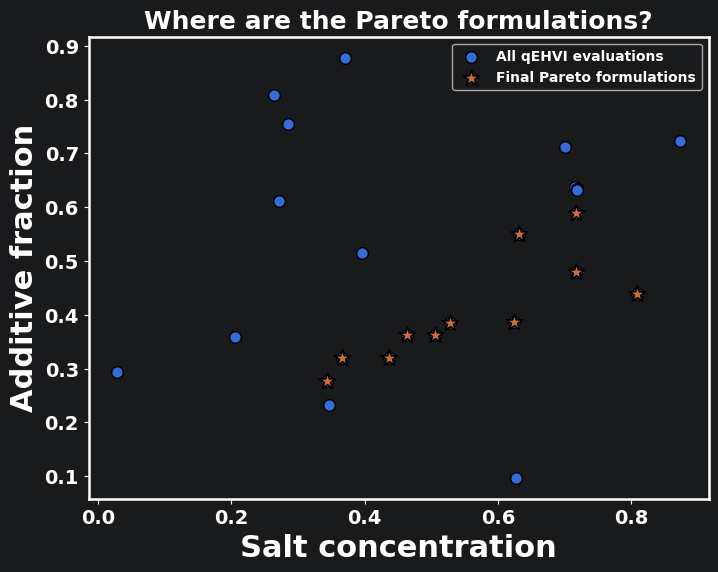

,salt_concentration,additive_fraction,coulombic_efficiency,charging_capacity
1,0.717272,0.589274,0.958849,235.000000
0,0.630919,0.549240,0.961653,223.585254
8,0.717016,0.479159,0.963920,219.676258
2,0.807777,0.438198,0.965179,204.289622
4,0.623474,0.386375,0.967578,192.720555
6,0.528208,0.384398,0.973070,179.446760
10,0.505291,0.362620,0.976662,173.290077
3,0.463353,0.362582,0.980614,167.088500
7,0.436408,0.320520,0.986752,159.247111
5,0.366561,0.319140,0.991785,148.809869


In [12]:
qehvi_final_X = qehvi_result["train_X_final"]
qehvi_final_Y = qehvi_result["train_Y_final"]

qehvi_pareto_mask = is_non_dominated(qehvi_final_Y)
qehvi_pareto_X = qehvi_final_X[qehvi_pareto_mask]
qehvi_pareto_Y = qehvi_final_Y[qehvi_pareto_mask]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    qehvi_final_X[:, 0],
    qehvi_final_X[:, 1],
    s=70,
    edgecolor="black",
    lw=1.0,
    label="All qEHVI evaluations",
)

ax.scatter(
    qehvi_pareto_X[:, 0],
    qehvi_pareto_X[:, 1],
    s=150,
    marker="*",
    edgecolor="black",
    lw=1.2,
    label="Final Pareto formulations",
)

ax.set_title("Where are the Pareto formulations?", fontsize=18, fontweight="bold")
ax.set_xlabel("Salt concentration", fontsize=22, fontweight="bold")
ax.set_ylabel("Additive fraction", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

pareto_df = pd.DataFrame({
    "salt_concentration": qehvi_pareto_X[:, 0].detach().cpu().numpy(),
    "additive_fraction": qehvi_pareto_X[:, 1].detach().cpu().numpy(),
    "coulombic_efficiency": qehvi_pareto_Y[:, 0].detach().cpu().numpy(),
    "charging_capacity": qehvi_pareto_Y[:, 1].detach().cpu().numpy(),
})

display(pareto_df.sort_values("coulombic_efficiency"))

## 12. Choosing one formulation from the Pareto set

The BO loop has now produced a final observed Pareto set.

That is an important result, but it is not the end of the decision-making process.

A Pareto frontier gives us a set of best trade-offs. It does not automatically tell us which single formulation should be chosen.

This cell introduces a few simple post-processing decision rules for selecting one final electrolyte formulation from the Pareto set.

---

### Why a decision rule is needed

In single-objective BO, choosing the final recommendation is usually straightforward: we pick the point with the best observed value or the best model-based value.

In multi-objective BO, this is no longer enough.

A Pareto set may contain several non-dominated formulations:

- one may have very high charging capacity but lower Coulombic efficiency,
- another may have very high Coulombic efficiency but lower capacity,
- another may offer a balanced compromise between the two.

None of these points dominates the others.

So choosing one final formulation requires an additional layer of preference.

That is what this cell demonstrates.

---

### Why the objectives are normalised first

The function `normalise_columns(Y)` rescales each objective column to the interval $[0,1]$ within the current Pareto set.

This is important because Coulombic efficiency and charging capacity have very different numerical scales.

Coulombic efficiency varies over a narrow range, roughly around $0.95$ to $0.99$.

Charging capacity varies over a much larger range, around hundreds of units.

If we used a weighted sum directly on the raw objective values, the capacity term would dominate simply because it has larger numbers.

Normalisation makes the objectives comparable before applying decision rules such as weighted scoring or distance to an ideal point.

---

### Decision rule 1: equal-weight score

The first rule is implemented by `select_weighted_sum(...)`.

It normalises the objectives and computes a weighted score:

$$
S(x) = w_1 \tilde{f}_{\text{eff}}(x) + w_2 \tilde{f}_{\text{cap}}(x),
$$

where $\tilde{f}_{\text{eff}}$ and $\tilde{f}_{\text{cap}}$ are normalised objective values.

In this cell, the default weights are

$$
(w_1, w_2) = (0.5, 0.5).
$$

So this rule treats Coulombic efficiency and charging capacity as equally important.

It selects the Pareto formulation with the highest equal-weight score.

This is a simple way to choose a balanced high-performing point, but it depends on the choice of weights.

---

### Decision rule 2: efficiency threshold, then maximise capacity

The second rule is implemented by `select_threshold_capacity(...)`.

This rule first filters the Pareto set to formulations satisfying

$$
f_{\text{eff}}(x) \ge 0.985.
$$

Among those acceptable high-efficiency formulations, it then chooses the one with the highest charging capacity.

This is often more realistic than a weighted sum in scientific optimisation.

For example, in an electrolyte problem, Coulombic efficiency may act like a minimum acceptability requirement. A formulation with poor efficiency may be unacceptable even if its capacity is high.

So this rule represents the logic:

> first meet the required efficiency standard, then maximise capacity.

If no formulation satisfies the efficiency threshold, the fallback rule selects the formulation with the highest efficiency.

---

### Decision rule 3: balanced compromise

The third rule is implemented by `select_balanced_compromise(...)`.

This rule also works on normalised objectives.

It defines the ideal objective vector as

$$
(1, 1),
$$

which would correspond to the best normalised value in both objectives.

Then it selects the Pareto formulation closest to this ideal point by Euclidean distance.

So this rule tries to find a balanced compromise that is close to the best available efficiency and the best available capacity at the same time.

It is useful when we do not want to prioritise one objective too aggressively.

---

### What the output table shows

The output table reports the formulation selected by each decision rule.

For each selected point, it shows:

- the decision rule used,
- the salt concentration,
- the additive fraction,
- the Coulombic efficiency,
- and the charging capacity.

The same Pareto set can therefore lead to different final recommendations depending on the decision rule.

That is not a weakness of multi-objective BO.

It is the point of multi-objective BO: the optimisation stage finds the trade-off set, and the decision stage chooses among those trade-offs according to scientific priorities.

---

### Key takeaway

This cell turns the final Pareto frontier into concrete formulation recommendations.

The Pareto set provides the best observed trade-offs, but choosing one final formulation still requires a preference rule.

Different rules encode different experimental priorities, such as equal weighting, minimum efficiency requirements, or balanced compromise.

So multi-objective BO separates two questions:

> what trade-offs are available?

and

> which trade-off do we prefer?

In [13]:
def normalise_columns(Y):
    Y_min = Y.min(dim=0).values
    Y_max = Y.max(dim=0).values
    return (Y - Y_min) / (Y_max - Y_min).clamp_min(1e-12)


def select_weighted_sum(X, Y, weights=torch.tensor([0.5, 0.5], dtype=torch.double)):
    Y_norm = normalise_columns(Y)
    scores = Y_norm @ weights
    idx = torch.argmax(scores)
    return idx, scores


def select_threshold_capacity(X, Y, efficiency_threshold=0.985):
    feasible = Y[:, 0] >= efficiency_threshold

    if feasible.any():
        feasible_indices = torch.where(feasible)[0]
        best_local = torch.argmax(Y[feasible_indices, 1])
        idx = feasible_indices[best_local]
        return idx, feasible
    else:
        idx = torch.argmax(Y[:, 0])
        return idx, feasible


def select_balanced_compromise(X, Y):
    Y_norm = normalise_columns(Y)
    ideal = torch.ones(Y_norm.shape[-1], dtype=Y_norm.dtype)
    distances = torch.linalg.norm(Y_norm - ideal, dim=-1)
    idx = torch.argmin(distances)
    return idx, distances


pareto_X = qehvi_pareto_X
pareto_Y = qehvi_pareto_Y

weighted_idx, weighted_scores = select_weighted_sum(pareto_X, pareto_Y)
threshold_idx, threshold_mask = select_threshold_capacity(
    pareto_X,
    pareto_Y,
    efficiency_threshold=0.985,
)
balanced_idx, balanced_distances = select_balanced_compromise(pareto_X, pareto_Y)

selected_indices = {
    "weighted_sum_equal_priority": weighted_idx,
    "efficiency_threshold_then_capacity": threshold_idx,
    "balanced_compromise": balanced_idx,
}

selected_rows = []

for rule_name, idx in selected_indices.items():
    selected_rows.append({
        "decision_rule": rule_name,
        "salt_concentration": float(pareto_X[idx, 0]),
        "additive_fraction": float(pareto_X[idx, 1]),
        "coulombic_efficiency": float(pareto_Y[idx, 0]),
        "charging_capacity": float(pareto_Y[idx, 1]),
    })

selected_df = pd.DataFrame(selected_rows)

display(selected_df)

,decision_rule,salt_concentration,additive_fraction,coulombic_efficiency,charging_capacity
0,weighted_sum_equal_priority,0.366561,0.319140,0.991785,148.809869
1,efficiency_threshold_then_capacity,0.436408,0.320520,0.986752,159.247111
2,balanced_compromise,0.463353,0.362582,0.980614,167.088500


## 13. Visualising final decision choices on the Pareto frontier

This cell brings together the final observed Pareto frontier and the three decision rules introduced in the previous section.

At this stage, qEHVI has already done its job: it has found a set of non-dominated formulations that represent different trade-offs between Coulombic efficiency and charging capacity.

The remaining question is no longer purely an optimisation question.

It is a decision question:

> which Pareto-optimal formulation should we actually choose?

---

### Why the Pareto frontier is sorted before plotting

The code first sorts the Pareto points by Coulombic efficiency:

`pareto_sort_idx = torch.argsort(qehvi_pareto_Y[:, 0])`

This is only for visualisation.

Pareto points are collected in the order they were evaluated, but connecting them in that raw order can make the frontier look like a tangled path.

Sorting by Coulombic efficiency makes the plotted line follow the trade-off curve cleanly from the high-capacity end to the high-efficiency end.

---

### What the figure shows

The faint circular markers show all qEHVI observations.

The connected line shows the final observed Pareto frontier.

The vertical dashed line marks the efficiency threshold used by one of the decision rules:

$$
f_{\text{eff}}(x) \ge 0.985.
$$

The large highlighted markers show the final formulations selected by different decision rules:

- **Equal-weight score**,
- **Threshold then capacity**,
- **Balanced compromise**.

These selected points all come from the same Pareto frontier, but they represent different priorities.

---

### Different rules lead to different final choices

This is the most important message of the cell.

The Pareto frontier gives us a set of rational candidate formulations, but it does not uniquely determine the final answer.

Different decision rules can select different points from the same frontier.

The **equal-weight score** rule chooses the point with the best combined normalised performance when Coulombic efficiency and charging capacity are treated as equally important.

The **threshold then capacity** rule first requires the formulation to satisfy the efficiency threshold, then chooses the highest-capacity option among those acceptable formulations.

The **balanced compromise** rule chooses the Pareto point closest to the ideal normalised objective vector $(1,1)$.

So the final recommendation depends on what kind of trade-off the user or experimental campaign prefers.

---

### Why this matters

This illustrates a key difference between single-objective and multi-objective BO.

In single-objective BO, the optimiser often returns one final best point.

In multi-objective BO, the optimiser returns a frontier of strong trade-offs.

Choosing one final point requires preferences, constraints, thresholds, or domain judgement.

That is not a weakness of the method.

It is one of its main advantages.

It allows the optimisation stage and the decision stage to remain separate:

- BO discovers what trade-offs are available,
- the decision rule determines which trade-off is most appropriate.

---

### Key takeaway

This cell shows that the same Pareto frontier can lead to different final formulation choices depending on the decision rule.

Multi-objective BO therefore does not simply answer “what is the best point?”

Instead, it gives a structured set of best trade-offs, and the final choice depends on how we prioritise the competing objectives.

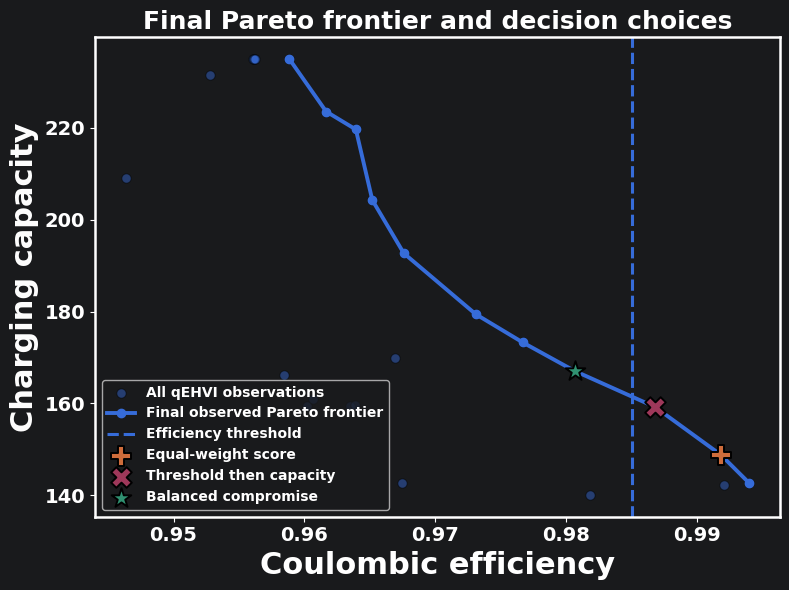

In [14]:
pareto_sort_idx = torch.argsort(qehvi_pareto_Y[:, 0])
pareto_Y_sorted = qehvi_pareto_Y[pareto_sort_idx]
pareto_X_sorted = qehvi_pareto_X[pareto_sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    qehvi_final_Y[:, 0],
    qehvi_final_Y[:, 1],
    s=45,
    alpha=0.45,
    edgecolor="black",
    lw=0.8,
    label="All qEHVI observations",
)

ax.plot(
    pareto_Y_sorted[:, 0],
    pareto_Y_sorted[:, 1],
    "-o",
    lw=2.8,
    markersize=6,
    label="Final observed Pareto frontier",
)

ax.axvline(
    0.985,
    linestyle="--",
    lw=2.2,
    label="Efficiency threshold",
)

markers = {
    "weighted_sum_equal_priority": "P",
    "efficiency_threshold_then_capacity": "X",
    "balanced_compromise": "*",
}

labels = {
    "weighted_sum_equal_priority": "Equal-weight score",
    "efficiency_threshold_then_capacity": "Threshold then capacity",
    "balanced_compromise": "Balanced compromise",
}

for rule_name, idx in selected_indices.items():
    ax.scatter(
        float(pareto_Y[idx, 0]),
        float(pareto_Y[idx, 1]),
        s=220,
        marker=markers[rule_name],
        edgecolor="black",
        linewidth=1.4,
        zorder=5,
        label=labels[rule_name],
    )

ax.set_title("Final Pareto frontier and decision choices", fontsize=18, fontweight="bold")
ax.set_xlabel("Coulombic efficiency", fontsize=22, fontweight="bold")
ax.set_ylabel("Charging capacity", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"}, loc="lower left")
style_ax(ax)
plt.tight_layout()
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from **noisy Bayesian Optimisation** to the problem of running BO when there are **multiple objectives to optimise at the same time**.

The central shift was that the meaning of “best” changed.

In a single-objective problem, BO can usually focus on improving one scalar value. In this notebook, the optimiser had to reason about two objectives at once:

$$
\max_x \left(f_{\text{eff}}(x), f_{\text{cap}}(x)\right),
$$

where the two objectives were **Coulombic efficiency** and **charging capacity**.

Because these objectives did not share the same optimum, the question was no longer:

> **which formulation is best?**

It became:

> **which formulations represent the best available trade-offs?**

That is the core idea of multi-objective BO.

---

The BO workflow still followed the familiar structure:

1. generate an initial design,
2. evaluate the objectives,
3. fit surrogate models,
4. construct an acquisition function,
5. propose the next candidate,
6. update the dataset,
7. and repeat.

But the meaning of progress changed.

Instead of tracking only the best observed value, we tracked the quality of the **Pareto frontier**: the set of formulations that cannot be improved in one objective without sacrificing at least one other objective.

This is why the tutorial introduced two central ideas:

- **Pareto optimality**,
- and **hypervolume**.

Pareto optimality tells us which formulations are rational trade-off candidates.

Hypervolume gives us a scalar way to measure how good the current Pareto set is as a whole.

So the notebook replaced “best value so far” with:

> **how much objective-space region is dominated by the current observed Pareto frontier?**

---

The synthetic electrolyte example made this trade-off visible.

The contour plots showed that Coulombic efficiency and charging capacity favoured different regions of formulation space.

The objective-space plot then showed the resulting Pareto frontier:

- high-capacity points had lower efficiency,
- high-efficiency points had lower capacity,
- and the middle of the frontier represented compromise formulations.

So one of the main lessons was:

> in multi-objective optimisation, the answer is often a frontier, not a point.

The initial Sobol design also showed the difference between the **observed Pareto set** and the **true Pareto frontier**.

The observed Pareto points were only non-dominated among the data collected so far. They were not guaranteed to be globally Pareto-optimal over the full search space.

That distinction matters because BO only knows the experiments it has already run. The goal is to improve the observed frontier over time.

---

The hypervolume section introduced the main progress diagnostic.

For a two-objective maximisation problem, the reference point defines the lower-left baseline from which dominated area is measured.

In this notebook, we used:

$$
(0.88, 115.0).
$$

This was deliberately chosen to sit below the useful objective region.

The reference point matters because hypervolume is always measured relative to it. A different reference point would change both the numerical hypervolume values and the behaviour of qEHVI.

So one practical lesson was:

> the reference point is not a harmless plotting parameter; it defines the region of objective space that the optimisation is trying to improve.

In real applications, it should reflect minimum acceptable performance or a scientifically meaningful region of interest.

---

The modelling step adapted the standard GP workflow to the multi-objective setting.

Instead of fitting one GP to one scalar target, the notebook fit one `SingleTaskGP` per objective and combined them using `ModelListGP`.

So the surrogate contained:

- one GP for Coulombic efficiency,
- and one GP for charging capacity.

This preserved the two-objective structure instead of collapsing the outputs into a weighted sum too early.

That was important because the purpose of the tutorial was to learn the trade-off frontier itself. If we had immediately combined the objectives into one weighted scalar, the result would have depended strongly on the chosen weights.

---

The qEHVI loop was the main optimisation workflow.

In single-objective BO, expected improvement asks how much a candidate is expected to improve the current best scalar value.

But here, there was no single best scalar value.

So qEHVI asked:

$$
\mathbb{E}[\Delta \text{Hypervolume}].
$$

In words:

> which next formulation is expected to expand the dominated hypervolume of the current Pareto frontier the most?

The BO loop still fit a model, proposed a candidate, evaluated the candidate, and updated the data.

But the acquisition function was now trying to improve the frontier of trade-offs, not one objective value.

---

The random Sobol baseline gave the qEHVI result a meaningful comparison.

Both methods started from the same initial data and used the same number of additional evaluations.

The difference was how new candidates were selected.

qEHVI used the surrogate model, uncertainty, Pareto structure, and hypervolume improvement.

Random Sobol search used non-adaptive space-filling sampling.

The hypervolume plot showed the difference clearly. qEHVI improved hypervolume rapidly and moved close to the approximate dense-grid hypervolume benchmark, while random search improved more slowly and plateaued lower.

So the lesson was:

> qEHVI was not merely benefiting from more samples; it was using the evaluation budget more efficiently to improve the trade-off frontier.

---

The final objective-space comparison made this visually clear.

qEHVI found observed Pareto points that spanned a large part of the approximate true Pareto frontier, including:

- the high-capacity end,
- the intermediate compromise region,
- and the high-efficiency end.

Random Sobol search found some non-dominated points too, but it covered the frontier less effectively.

The input-space plot then connected these Pareto points back to actual formulation choices. The final Pareto formulations corresponded to concrete salt concentration and additive fraction values.

So another important lesson was:

> the Pareto frontier is not just an objective-space curve; it corresponds to experimentally meaningful formulation choices.

---

The final decision-rule section addressed the last practical issue.

A Pareto frontier gives us a set of rational candidates, but it does not choose one final formulation automatically.

That final choice depends on preferences.

The notebook demonstrated three simple decision rules:

- an **equal-weight score**,
- an **efficiency-threshold-then-capacity** rule,
- and a **balanced compromise** rule.

These rules selected different points from the same Pareto frontier.

That was not a contradiction. It was the point.

Multi-objective BO separates two stages:

- first, learn the best available trade-offs,
- then, choose among those trade-offs according to scientific priorities.

For electrolyte optimisation, this is especially realistic. Coulombic efficiency may act as a minimum acceptability requirement, while capacity may be optimised only after that threshold is satisfied.

---

This tutorial focused deliberately on the **two-objective, noiseless qEHVI setting**.

That kept the conceptual emphasis on:

- Pareto optimality,
- hypervolume improvement,
- qEHVI,
- objective-space trade-offs,
- and post-BO decision-making.

There are two natural extensions.

First, for **noisy multi-objective observations**, the natural acquisition function is **qNEHVI** rather than qEHVI. qNEHVI plays the same conceptual role as qEHVI, but accounts for noise in the observed objectives and uncertainty in the current Pareto baseline.

Second, for **more than two objectives**, the same Pareto and hypervolume ideas still apply. A point is still Pareto-optimal if no other point improves all objectives at once, and hypervolume still measures the dominated region relative to a reference point.

However, visualisation and final decision-making become more difficult. With two objectives, the Pareto frontier can be drawn as a curve. With three objectives, it becomes a surface. With more objectives, it becomes a higher-dimensional trade-off set that usually requires projections, tables, scalar summaries, or explicit preference rules.

---

By the end of this tutorial, we adapted the standard BO structure to a richer optimisation target:

- one with multiple objectives,
- one with no unique global best point,
- one where progress is measured by Pareto-frontier improvement,
- and one where the final recommendation depends on decision preferences.

That gives us a natural stopping point:

> we now know how to build, run, and interpret a basic multi-objective BO workflow using Pareto optimality, hypervolume, and qEHVI.

Looking forward, this connects naturally to the rest of **Part 6**.

If Tutorial 1 asked how BO changes when observations are noisy, Tutorial 2 showed how BO changes when objectives are plural.

The next extensions can ask what happens when evaluations occur at different fidelities, when optimisation depends on context, or when design spaces become structured or combinatorial.

So the main takeaway of this tutorial is:

> once there are multiple objectives, BO should not be judged by whether it finds one best point, but by how well it learns and improves the frontier of useful trade-offs.